# TMDB Movie Data Analysis

## Step 1: Fetching Raw Movie Data from the TMDB API

The raw movie data is fetched using The Movie Database (TMDB) API.  
The helper function defined in the `data_fetcher.py` is used for fecthing the day.

In [1]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [8]:
from dotenv import load_dotenv
import os

api_key = os.getenv("TMDB_API_KEY")

In [9]:
print("API KEY:", os.getenv("TMDB_API_KEY"))

API KEY: 356d9ae6fc108307ae1b5f6358da93ee


In [10]:
# System setup to access external Python scripts
import sys
import os

sys.path.append(os.path.abspath('../scripts'))
import pandas as pd

# Import fetching function
from data_fetcher import fetch_tmdb_data

# Define API parameters
api_key = os.getenv("TMDB_API_KEY")
movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

# Fetch raw data
df_raw = fetch_tmdb_data(movie_ids, api_key)

# Preview first few rows of the dataset
df_raw.head()

Failed to fetch movie with ID: 0


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,...,2799439100,181,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.237,26246,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,2923706026,162,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.588,32159,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,...,2068223624,136,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.261,19691,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,...,2052415039,149,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.235,30431,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,...,2264162353,194,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on Earth could come between them.,Titanic,False,7.906,25912,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."


In [11]:
print("Expected:", len(movie_ids))
print("Fetched:", len(df_raw))

Expected: 19
Fetched: 18


In [4]:
df_raw.to_csv("../data/raw_movies.csv", index=False)

# Step 2: Data Cleaning and Preprocessing

In [4]:
# Import all data cleaning utilities
from data_cleaning import (
    parse_credits_column, extract_cast_crew_info, drop_irrelevant_columns,
    extract_all_fields, convert_column_datatypes, replace_unrealistic_values,
    convert_to_million, adjust_vote_average_by_genre, replace_placeholders,
    drop_duplicates_and_missing_ids_titles, drop_sparse_rows, filter_released_movies,
    reorder_columns, reset_dataframe_index
)

In [5]:
# Make a copy of the raw data to clean
df_clean = df_raw.copy()

In [6]:
# Handle 'credits' column
df_clean = parse_credits_column(df_clean)
df_cast_crew = df_clean['credits'].apply(extract_cast_crew_info)
df_clean = pd.concat([df_clean, df_cast_crew], axis=1)

In [7]:
# Drop unnecessary columns
columns_to_drop = ['credits', 'video', 'adult', 'homepage', 'imdb_id', 'original_title', 'backdrop_path']
df_clean = drop_irrelevant_columns(df_clean, columns_to_drop)

In [8]:
# Extract relevant fields from JSON columns
df_clean = extract_all_fields(df_clean)

In [9]:
# Convert column data types
df_clean = convert_column_datatypes(df_clean)

In [10]:
# Handle unrealistic numeric values
df_clean = replace_unrealistic_values(df_clean)

C:\Users\HP\Desktop\Data Projects\tmdb_project\scripts\data_cleaning.py:129: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['budget'].replace(0, np.nan, inplace=True)
C:\Users\HP\Desktop\Data Projects\tmdb_project\scripts\data_cleaning.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [11]:
# Convert budget & revenue to millions
df_clean = convert_to_million(df_clean)

In [12]:
# Adjust vote_average for movies with vote_count == 0 
df_clean = adjust_vote_average_by_genre(df_clean)

In [13]:
# Replace placeholder texts with NaN
df_clean = replace_placeholders(df_clean)

In [14]:
# Drop duplicates and missing ids/titles
df_clean = drop_duplicates_and_missing_ids_titles(df_clean)

In [15]:
# Drop sparse rows with too many missing values 
df_clean = drop_sparse_rows(df_clean, min_non_null=10)

In [16]:
# Keep only released movies
df_clean = filter_released_movies(df_clean)

In [17]:
# Reorder columns for final dataset
df_clean = reorder_columns(df_clean)

In [18]:
# Reset index 
df_clean = reset_dataframe_index(df_clean)

In [19]:
df_clean.head()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,597,Titanic,Nothing on Earth could come between them.,1997-11-18,Drama,None,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,7.906,49.1281,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,258
1,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Fantasy,Harry Potter Collection,en,125.0,1341.511219,Warner Bros. Pictures|Heyday Films,...,8.087,23.3456,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,104,David Yates,154
2,19995,Avatar,Enter the world of Pandora.,2009-12-15,Action,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.588,31.6851,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,986
3,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,7.739,46.7321,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,631
4,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action,The Avengers Collection,en,365.0,1405.403694,Marvel Studios,...,7.271,23.6961,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,636


In [20]:
df_clean.to_csv("../data/clean_movies.csv", index=False)

# Step 3: KPI Implementation & Analysis

In [21]:
# Load the cleaned dataset
df_clean = pd.read_csv("../data/clean_movies.csv")

In [22]:
from kpi_and_analysis import (
    calculate_profit, calculate_roi, kpi_ranking, filter_movies,
    franchise_vs_standalone, most_successful_franchises, most_successful_directors
)

In [23]:
# Calculate KPI Rankings
kpi_results = kpi_ranking(df_clean)
print("KPI Rankings:", kpi_results)

KPI Rankings: {'Highest Revenue':       id   title                      tagline release_date  genres  \
2  19995  Avatar  Enter the world of Pandora.   2009-12-15  Action   

  belongs_to_collection original_language  budget_musd  revenue_musd  \
2     Avatar Collection                en        237.0   2923.706026   

                                production_companies  ... runtime  \
2  Dune Entertainment|Lightstorm Entertainment|20...  ...     162   

                                            overview  spoken_languages  \
2  In the 22nd century, a paraplegic Marine is di...   English|Spanish   

                        poster_path  \
2  /kyeqWdyUXW608qlYkRqosgbbJyK.jpg   

                                                cast cast_size       director  \
2  Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...        65  James Cameron   

  crew_size       profit   roi  
2       986  2686.706026  None  

[1 rows x 24 columns], 'Highest Budget':       id                    title         

In [24]:
# Search Queries
# Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis
search_1 = filter_movies(df_clean, genre="Science Fiction|Action", actor="Bruce Willis", sort_by="vote_average")
print("\nBest-rated Science Fiction Action Movies starring Bruce Willis:", search_1)


Best-rated Science Fiction Action Movies starring Bruce Willis: Empty DataFrame
Columns: [id, title, tagline, release_date, genres, belongs_to_collection, original_language, budget_musd, revenue_musd, production_companies, production_countries, vote_count, vote_average, popularity, runtime, overview, spoken_languages, poster_path, cast, cast_size, director, crew_size, profit, roi]
Index: []

[0 rows x 24 columns]


In [25]:
# Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino
search_2 = filter_movies(df_clean, actor="Uma Thurman", director="Quentin Tarantino", sort_by="runtime")
print("\nMovies starring Uma Thurman, directed by Quentin Tarantino:", search_2)


Movies starring Uma Thurman, directed by Quentin Tarantino: Empty DataFrame
Columns: [id, title, tagline, release_date, genres, belongs_to_collection, original_language, budget_musd, revenue_musd, production_companies, production_countries, vote_count, vote_average, popularity, runtime, overview, spoken_languages, poster_path, cast, cast_size, director, crew_size, profit, roi]
Index: []

[0 rows x 24 columns]


In [26]:
# Franchise vs Standalone Movie Comparison
franchise_stats, standalone_stats = franchise_vs_standalone(df_clean)
print("\nFranchise Movie Stats:", franchise_stats)
print("Standalone Movie Stats:", standalone_stats)


Franchise Movie Stats: {'Mean Revenue': np.float64(1682.6419708125), 'Median ROI': np.float64(nan), 'Mean Budget': np.float64(219.875), 'Mean Popularity': np.float64(27.28914375), 'Mean Rating': np.float64(7.3805)}
Standalone Movie Stats: {'Mean Revenue': np.float64(1765.1391585000001), 'Median ROI': np.float64(nan), 'Mean Budget': np.float64(180.0), 'Mean Popularity': np.float64(41.9072), 'Mean Rating': np.float64(7.4384999999999994)}


C:\Users\HP\anaconda3\envs\work_environment\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\HP\anaconda3\envs\work_environment\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [27]:
# Most Successful Franchises
franchise_success = most_successful_franchises(df_clean)
print("\nMost Successful Movie Franchises:", franchise_success)


Most Successful Movie Franchises:                                      movie_count  total_budget  mean_budget  \
belongs_to_collection                                                         
The Avengers Collection                        4        1241.0       310.25   
Frozen Collection                              2         300.0       150.00   
Star Wars Collection                           2         445.0       222.50   
Jurassic Park Collection                       2         320.0       160.00   
Black Panther Collection                       1         200.0       200.00   
Avatar Collection                              1         237.0       237.00   
Harry Potter Collection                        1         125.0       125.00   
The Fast and the Furious Collection            1         190.0       190.00   
The Incredibles Collection                     1         200.0       200.00   
The Lion King (Reboot) Collection              1         260.0       260.00   

                

In [28]:
# Most Successful Directors
director_success = most_successful_directors(df_clean)
print("\nMost Successful Directors:", director_success)


Most Successful Directors:                  movie_count  total_revenue  mean_rating
director                                                
Joss Whedon                2    2924.219209        7.505
Joe Russo                  2    4851.854139        8.236
James Cameron              2    5187.868379        7.747
Colin Trevorrow            1    1671.537444        6.693
Bill Condon                1    1266.115964        6.971
Brad Bird                  1    1242.805359        7.454
Chris Buck                 1    1274.219009        7.247
J.J. Abrams                1    2068.223624        7.261
J.A. Bayona                1    1310.466296        6.537
David Yates                1    1341.511219        8.087
James Wan                  1    1515.400000        7.200
Jennifer Lee               1    1453.683476        7.250
Jon Favreau                1    1662.020819        7.110
Rian Johnson               1    1332.698830        6.779
Ryan Coogler               1    1349.926083        7.400


# Step 4: Data Visualization

In [58]:
import importlib
import visualizations
importlib.reload(visualizations)

from visualizations import plot_yearly_trends
from visualizations import plot_roi_distribution_by_genre

In [59]:
# import all functions needed
from visualizations import (
    plot_revenue_vs_budget,
    plot_roi_distribution_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_trends,
    plot_franchise_vs_standalone,
)

# Ensure this function is still available in data_cleaning.py if needed
from data_cleaning import convert_to_million

In [60]:
# Load the clean dataset
df_clean = pd.read_csv("../data/clean_movies.csv")

Plotting Revenue vs Budget Trends...


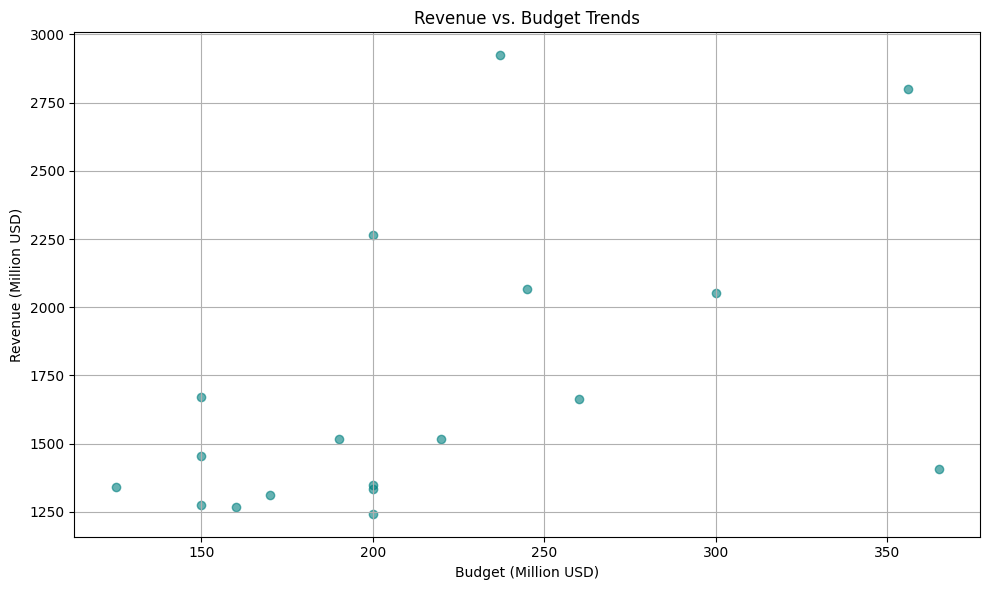

In [61]:
from visualizations import plot_revenue_vs_budget

print("Plotting Revenue vs Budget Trends...")
plot_revenue_vs_budget(df_clean)

Plotting ROI Distribution by Genre...


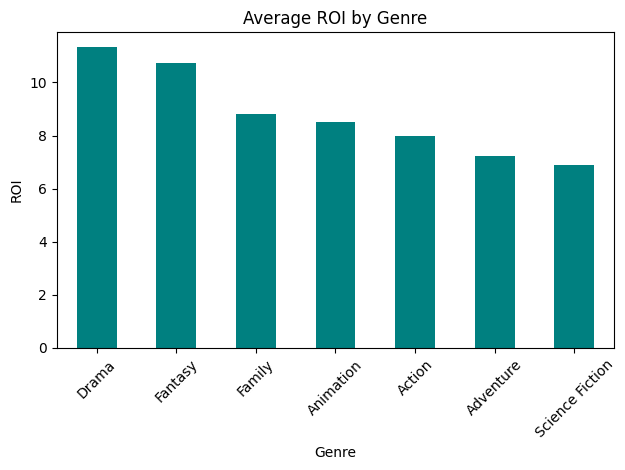

In [63]:
print("Plotting ROI Distribution by Genre...")
plot_roi_distribution_by_genre(df_clean)

Plotting Popularity vs Rating...


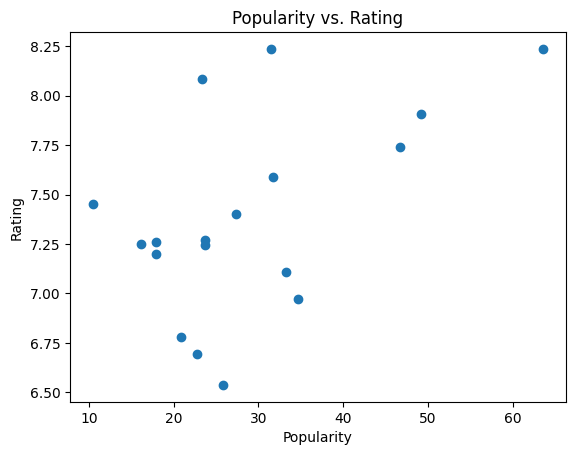

In [64]:
# Plot Popularity vs Rating
print("Plotting Popularity vs Rating...")
plot_popularity_vs_rating(df_clean)

Plotting Yearly Trends in Box Office Performance...


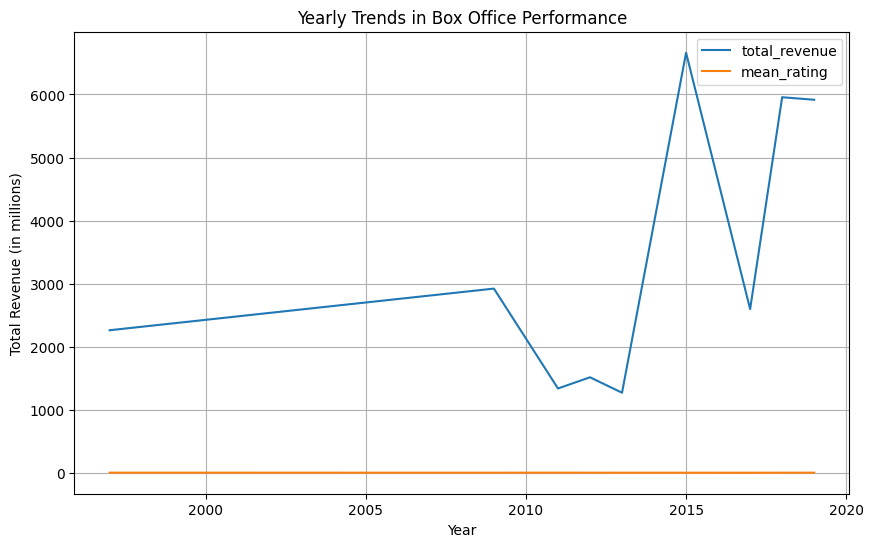

In [65]:
# Plot Yearly Trends in Box Office Performance
print("Plotting Yearly Trends in Box Office Performance...")
plot_yearly_trends(df_clean)

In [66]:
# Create 'is_franchise' column from 'belongs_to_collection'
df_clean['is_franchise'] = df_clean['belongs_to_collection'].notnull().astype(int)

Plotting Franchise vs Standalone Success...


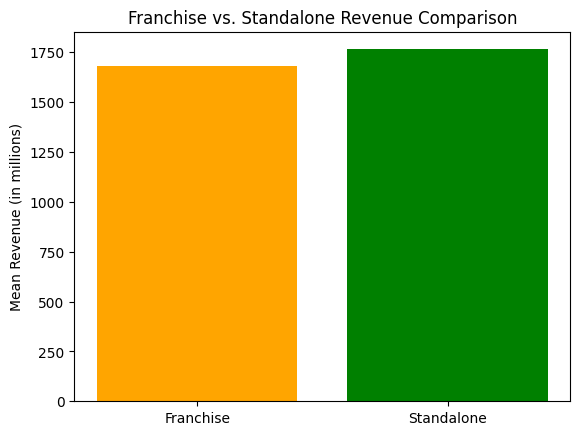

In [67]:
# Plot Franchise vs Standalone Success
print("Plotting Franchise vs Standalone Success...")
plot_franchise_vs_standalone(df_clean)